<a href="https://colab.research.google.com/github/Ahmed-Mohammed-x/NLP-support-ticket-classifier/blob/main/customer_support_classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NLP Support Ticket Classifier

This notebook evaluates three classical NLP models for predicting `Ticket Type`
from `Ticket Subject` and `Ticket Description`. The models are compared using
five-fold cross-validation macro F1 and the selected model is evaluated on a
separate test set.

### **1. Data preparation**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import files
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import make_pipeline
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

# Open the file-upload button
uploaded = files.upload()

# Automatically use the uploaded filename
filename = next(iter(uploaded))

# Load the selected dataset
df = pd.read_csv(filename)

required = [
    "Ticket Subject",
    "Ticket Description",
    "Ticket Type"
]

# Inspect data quality
print("Loaded file:", filename)
print("Shape:", df.shape)

print("\nMissing values:")
print(df[required].isna().sum())

print("\nDuplicate description-label rows:")
print(
    df.duplicated(
        subset=["Ticket Description", "Ticket Type"]
    ).sum()
)

print("\nClass distribution:")
print(df["Ticket Type"].value_counts())

# Remove unusable and duplicated records
df = (
    df.dropna(subset=required)
      .drop_duplicates(
          subset=["Ticket Description", "Ticket Type"]
      )
      .copy()
)

# Combine the two text fields
df["text"] = (
    df["Ticket Subject"] + " " + df["Ticket Description"]
)

print("\nRows after cleaning:", len(df))

Saving customer_support_tickets.csv to customer_support_tickets (1).csv
Loaded file: customer_support_tickets (1).csv
Shape: (8469, 17)

Missing values:
Ticket Subject        0
Ticket Description    0
Ticket Type           0
dtype: int64

Duplicate description-label rows:
279

Class distribution:
Ticket Type
Refund request          1752
Technical issue         1747
Cancellation request    1695
Product inquiry         1641
Billing inquiry         1634
Name: count, dtype: int64

Rows after cleaning: 8190


### **2. Model comparison**

In [2]:
# Keep 20% of the data untouched for final evaluation
X_train, X_test, y_train, y_test = train_test_split(
    df["text"],
    df["Ticket Type"],
    test_size=0.2,
    stratify=df["Ticket Type"],
    random_state=42
)

models = {
    "Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),
    "LinearSVC": LinearSVC(random_state=42)
}

# Compare all models using the same TF-IDF representation
results = {}

for name, model in models.items():
    pipeline = make_pipeline(
        TfidfVectorizer(ngram_range=(1, 2)),
        model
    )

    scores = cross_val_score(
        pipeline,
        X_train,
        y_train,
        cv=5,
        scoring="f1_macro"
    )

    results[name] = scores.mean()
    print(f"{name}: {scores.mean():.3f} ± {scores.std():.3f}")

Naive Bayes: 0.182 ± 0.009
Logistic Regression: 0.188 ± 0.006
LinearSVC: 0.191 ± 0.006


## **3. Final evaluation**


Selected model: LinearSVC

Final test results:
                      precision    recall  f1-score   support

     Billing inquiry       0.18      0.16      0.17       318
Cancellation request       0.16      0.16      0.16       328
     Product inquiry       0.19      0.18      0.19       320
      Refund request       0.22      0.22      0.22       338
     Technical issue       0.20      0.21      0.21       334

            accuracy                           0.19      1638
           macro avg       0.19      0.19      0.19      1638
        weighted avg       0.19      0.19      0.19      1638



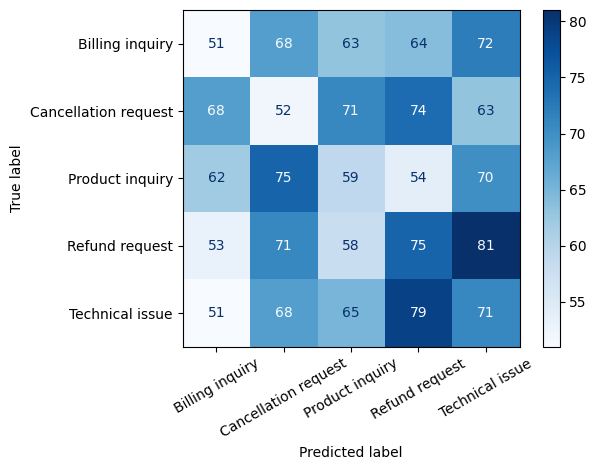

In [3]:
# Select the model with the highest cross-validation macro F1
best_name = max(results, key=results.get)

final_model = make_pipeline(
    TfidfVectorizer(ngram_range=(1, 2)),
    models[best_name]
)

final_model.fit(X_train, y_train)
predictions = final_model.predict(X_test)

print("\nSelected model:", best_name)
print("\nFinal test results:")
print(classification_report(y_test, predictions))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    predictions,
    xticks_rotation=30,
    cmap="Blues"
)

plt.tight_layout()
plt.show()

## Conclusion

The dataset contained 8,469 rows and no missing values in the required
columns. After removing 279 duplicate description-label records, 8,190 rows
remained.

Among the three candidate models, LinearSVC achieved the highest
cross-validation macro F1 of 0.191, compared with 0.188 for Logistic Regression
and 0.182 for Multinomial Naive Bayes.

LinearSVC was therefore selected for final evaluation. It achieved a test
accuracy and macro F1 of approximately 0.19. The confusion matrix showed that
the model frequently confused all five ticket types.

The weak performance suggests that the ticket subjects and descriptions do not
contain enough reliable information to predict the supplied Ticket Type labels.
The current classifier is therefore not suitable for dependable ticket routing.